Using device: cuda
Epoch 50, Loss: -2.7102434635162354
Epoch 100, Loss: -3.7876229286193848
Epoch 150, Loss: -3.1749346256256104
Epoch 200, Loss: -3.226508617401123
Epoch 250, Loss: -2.78482723236084
Epoch 300, Loss: -3.5547659397125244
Epoch 350, Loss: -2.585463523864746
Epoch 400, Loss: -2.4951682090759277
Epoch 450, Loss: -1.1917810440063477
Epoch 500, Loss: -4.264707088470459
Final samples shape: (200000, 6)
Final data_tensor shape: torch.Size([70000, 7])
Generated 200000 valid samples.


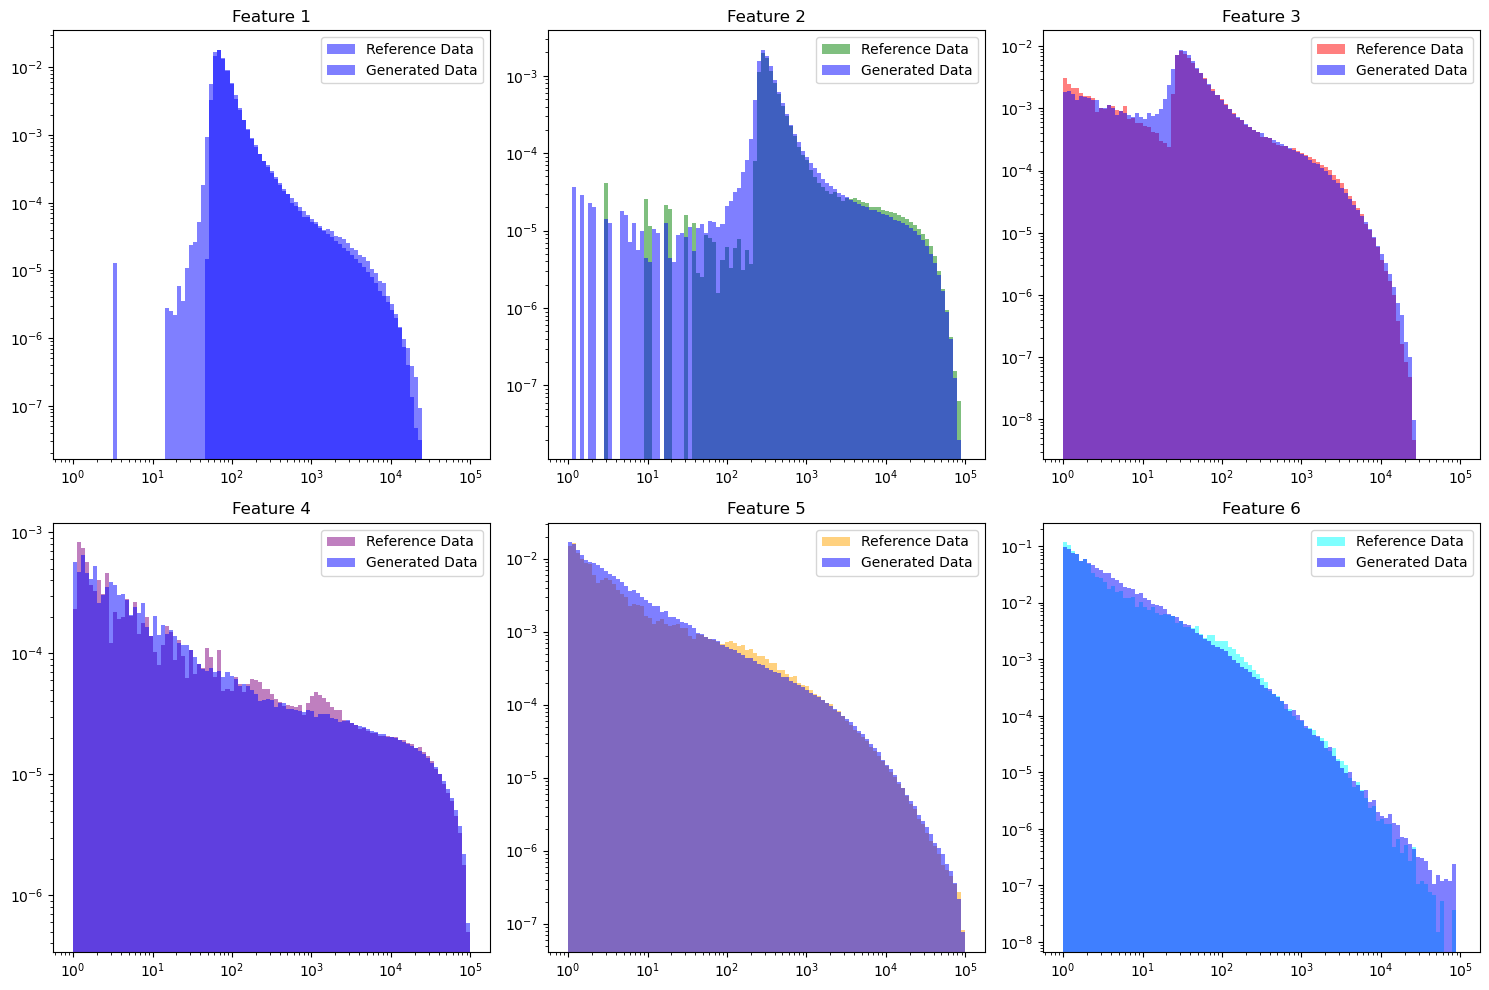

In [1]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)


def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

start_time = time.time()

# load and preprocess data
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

# combine energy & layers
data = np.hstack((energy.reshape(-1, 1), E_layers))

# replace inf with NaN for filterning
data[np.isinf(data)] = np.nan
# remove rows with NaN values
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

# convert to tensor
data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

# normalize and logit transform todo: f einc PREP1
data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

# debug
if torch.isnan(data_tensor).any() or torch.isinf(data_tensor).any():
    raise ValueError("Data tensor contains NaN or Inf values after transformations.")

# remove nan and inf
mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

# normalize to zero mean and unit variance (?)todo: einc PREP2
data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

# split the data tensor into context feature and training features
context_feature = data_tensor[:, 0].unsqueeze(1)  # context
input_features = data_tensor[:, 1:]  #layer features

# define flow model
num_layers = 5 #todo:  6-10
base_distribution = StandardNormal(shape=[input_features.shape[1]])  # shape matches input featurs (excl. context)
transforms = []

for _ in range(num_layers):
    #permutation to shuffle features
    transforms.append(ReversePermutation(features=input_features.shape[1]))
    # Add the MaskedAffineAutoregressiveTransform with context features #transforms.MaskedPiecewiseRationalQuadraticAutoregressiveTransform statt maskedaffineautoreg.. 
    transforms.append(MaskedAffineAutoregressiveTransform(
        features=input_features.shape[1],  # exclude the context feature (corr?)
        hidden_features=64,
        context_features=1  # context is one feature (first column) (corr?)
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

# train the flow model
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 500 #orig 500, nur zu testzwecken kleiner gesetzt
batch_size = 256
best_loss = float('inf')

#TODO: torch data set/ dataloader - from torch. utils. data import dataloader
# Initialize best model path
best_model_path = "best_flow_model.pth"
for epoch in range(num_epochs):
    # shuffle data
    idx = torch.randperm(len(data_tensor))
    data_tensor = data_tensor[idx]

    # split data into context and input features
    context_feature = data_tensor[:, 0].unsqueeze(1)  # 1. spalte
    input_features = data_tensor[:, 1:]  # remaining columns

    for i in range(0, len(input_features), batch_size):
        # create batches for input and context
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]

        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()

        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            best_loss = min(best_loss, loss.item())
            
        # Update best model
       # if loss.item() < best_loss:
          #  best_loss = loss.item()
           # torch.save(flow.state_dict(), best_model_path)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

        
#flow.load_state_dict(torch.load(best_model_path, weights_only=True))
import torch.nn.functional as F

# generate samples
n_samples = len(data_tensor)
n_samples = 200000
batch_size = 1000
all_samples = []

# Preprocess Einc using the same steps as the training data (corr?)
Einc_gen = torch.rand((n_samples,1)).to(device) *99+1 # todo: separat speichern
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]  # standardize



# context is expanded for each batch
with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        current_batch_size = min(batch_size, n_samples - i)  #last batch otherwise prod. error
       # batch_context = Einc.repeat(current_batch_size, 1)
        #n split um batches mit einc
        batch_context = Einc_gen[i:i+batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()

        all_samples.append(samples_batch)

# since all samples now same size -> cat
samples = torch.cat(all_samples, dim=0)#100000,6


samples = samples *data_std[1:].cpu()+ data_mean[1:].cpu() 
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()
   
# Final adjustment if needed
print(f"Final samples shape: {samples.shape}")
print(f"Final data_tensor shape: {data_tensor.shape}")
print(f"Generated {len(samples)} valid samples.")

# histogramme
#num_features = data.shape[1] 
#fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
#axs = axs.flatten()


colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']
# ensure samples are valid before plotting
#if torch.isnan(samples).any() or torch.isinf(samples).any():
 #   raise ValueError("Samples contain NaN or Inf values before plotting.")

# exclude the context feature (first column of data)
# histogramme
num_features = data.shape[1] - 1
fig, axs = plt.subplots(2, 3, figsize=(15, 10)) 
axs = axs.flatten()


colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(num_features): 
    #bins = 500 if len(data[:, i+1]) > 500 else len(data[:, i+1])  
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1],  #exclude context feature
        bins=bins,
        alpha=0.5,
        label="Reference Data",
        color=colors[i % len(colors)],  
        density=True,
        log=True
    )
    axs[i].hist(
        samples[:, i],
        bins=bin_edges,
        alpha=0.5,
        label="Generated Data",
        color='blue',  
        density=True,
        log=True
    )
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")  

for j in range(len(axs)):
    if j >= num_features:
        axs[j].axis('off')

plt.tight_layout()
plt.show()

In [2]:
#CLASSIFIER
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler #changed
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

real_data = data[:, 1:].copy() #changed
generated_data = samples.copy() #changed
generated_data = generated_data[np.isfinite(generated_data).all(axis=1)] #changed

# Create labels
smallest_size = min(len(real_data), len(generated_data))

# Randomly select smallest_size indices
real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

# Select only those samples
real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

# combining of real and KDE gen data
combined_data = np.vstack((real_data, generated_data)) #changed
combined_labels = np.hstack((real_labels, maf_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels) #changed
scaler = StandardScaler() #changed
X_train = scaler.fit_transform(X_train) #changed
X_test = scaler.transform(X_test) #changed

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x) #changed
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    probs = torch.sigmoid(outputs) #changed
                    preds = torch.round(probs) #changed

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_scores = [] #changed
    all_preds = []
    all_labels = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            scores = torch.sigmoid(outputs) #changed
            preds = torch.round(scores) #changed
            all_scores.append(scores.cpu().numpy()) #changed
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_scores = np.concatenate(all_scores) #changed
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_scores) #changed
    print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False) #changed
}

# model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss() #changed
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)
end_time = time.time()
elapsed_time = end_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total time taken: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

Final real data shape: (70000, 6)
Final gen shape: (70000, 6)
Epoch number 0/24
----------
train Loss: 0.6905 Acc: 0.5343
val Loss: 0.6896 Acc: 0.5403
Epoch number 1/24
----------
train Loss: 0.6890 Acc: 0.5412
val Loss: 0.6877 Acc: 0.5456
Epoch number 2/24
----------
train Loss: 0.6876 Acc: 0.5434
val Loss: 0.6862 Acc: 0.5455
Epoch number 3/24
----------
train Loss: 0.6866 Acc: 0.5471
val Loss: 0.6857 Acc: 0.5466
Epoch number 4/24
----------
train Loss: 0.6860 Acc: 0.5468
val Loss: 0.6848 Acc: 0.5440
Epoch number 5/24
----------
train Loss: 0.6853 Acc: 0.5494
val Loss: 0.6843 Acc: 0.5451
Epoch number 6/24
----------
train Loss: 0.6844 Acc: 0.5501
val Loss: 0.6844 Acc: 0.5443
Epoch number 7/24
----------
train Loss: 0.6845 Acc: 0.5490
val Loss: 0.6839 Acc: 0.5439
Epoch number 8/24
----------
train Loss: 0.6839 Acc: 0.5491
val Loss: 0.6836 Acc: 0.5478
Epoch number 9/24
----------
train Loss: 0.6839 Acc: 0.5512
val Loss: 0.6829 Acc: 0.5480
Epoch number 10/24
----------
train Loss: 0.6836

data_max_reg[0] = 99.99932861328125
E_inc=10 GeV: mean error = 0.05, std = 2.30, sat = 0.00%, time = 28.76s
  Bin fraction at true energy: 27.37%
  FWHM: 3.57 GeV
E_inc=20 GeV: mean error = 0.28, std = 3.37, sat = 0.00%, time = 28.76s
  Bin fraction at true energy: 19.30%
  FWHM: 4.76 GeV
E_inc=30 GeV: mean error = 0.37, std = 4.17, sat = 0.00%, time = 28.83s
  Bin fraction at true energy: 14.06%
  FWHM: 7.14 GeV
E_inc=40 GeV: mean error = 0.39, std = 4.88, sat = 0.00%, time = 28.78s
  Bin fraction at true energy: 12.43%
  FWHM: 8.33 GeV
E_inc=50 GeV: mean error = 0.44, std = 5.56, sat = 0.01%, time = 28.76s
  Bin fraction at true energy: 10.18%
  FWHM: 10.71 GeV
E_inc=60 GeV: mean error = 0.38, std = 5.99, sat = 0.03%, time = 29.48s
  Bin fraction at true energy: 10.24%
  FWHM: 10.71 GeV
E_inc=70 GeV: mean error = 0.28, std = 6.60, sat = 0.18%, time = 28.30s
  Bin fraction at true energy: 8.18%
  FWHM: 10.71 GeV
E_inc=80 GeV: mean error = 0.06, std = 6.76, sat = 1.28%, time = 28.73s
 

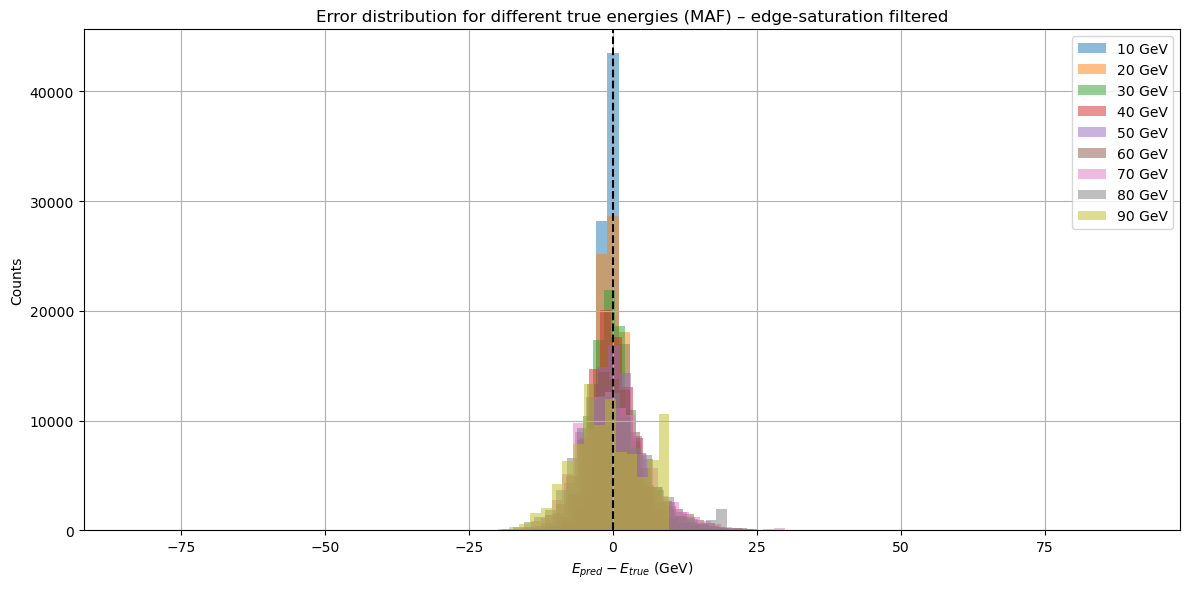

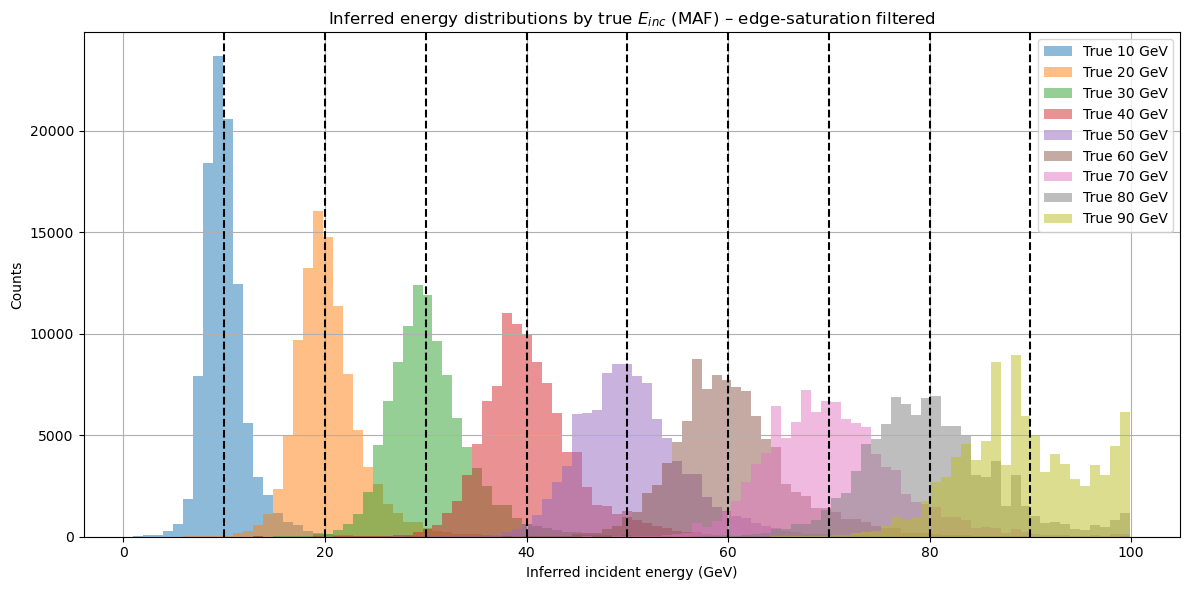


=== Per-energy regression summary (edge-saturation filtered) ===
E_true [GeV]        N   Bias [GeV]  MAE [GeV]  RMSE [GeV]  Std [GeV]  68% width [GeV]  Sat. frac
        10    99997        0.048      1.572       2.305      2.305            3.465      0.00%
        20    99998        0.282      2.382       3.377      3.366            5.445      0.00%
        30   100000        0.372      3.039       4.188      4.171            7.128      0.00%
        40    99997        0.387      3.545       4.893      4.878            8.217      0.00%
        50    99993        0.441      4.140       5.578      5.560            9.999      0.01%
        60    99967        0.377      4.416       5.999      5.987            9.999      0.03%
        70    99817        0.282      4.999       6.605      6.599           11.781      0.18%
        80    98721        0.063      5.108       6.759      6.759           12.276      1.28%
        90    94157       -0.883      5.111       6.360      6.298           

In [3]:
# REGRESSION EVALUATION
import os
import time
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))   # 10,20,...,90


Emin = 1.0
Emax = 120.0          
num_scan_points = 1000
batch_size = 10000

errors_by_energy = {}
inferred_by_energy = {}     
sat_frac_by_energy = {}      


def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x,
                          min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)


def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg, device):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    data = data[~np.isnan(data).any(axis=1)]

    x = torch.tensor(data, dtype=torch.float32, device=device)
    x = x / data_max_reg
    x = logit_trafo_reg(x)
    x = (x - data_mean_reg) / data_std_reg

    return x[:, 1:]   # only layers

def infer_incident_energy(flow, layer_tensor,
                          data_mean_reg, data_std_reg, data_max_reg,
                          num_scan_points=1000, Emin=1.0, Emax=120.0,
                          batch_size=10000):

    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]


    Emax_eff = float(data_max_reg[0].item()) * 0.999
    E_candidates = torch.linspace(Emin, Emax_eff, num_scan_points,device=device).view(-1, 1)
    E_norm  = E_candidates / data_max_reg[0]
    E_logit = logit_trafo_reg(E_norm)
    E_std   = (E_logit - data_mean_reg[0]) / data_std_reg[0]

    E_context = E_std.view(1, -1, 1).repeat(n_samples, 1, 1)
    inputs    = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)

    flat_inputs  = inputs.view(-1, inputs.shape[-1])
    flat_context = E_context.view(-1, 1)

    log_probs_list = []
    flow.eval()
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            logp = flow.log_prob(flat_inputs[i:i+batch_size],
                                 context=flat_context[i:i+batch_size])
            log_probs_list.append(logp)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
    max_indices = log_probs.argmax(dim=1)

    inferred_E = E_candidates[max_indices].squeeze(1).cpu().numpy()
    return inferred_E, max_indices.cpu().numpy()

data_mean_reg = data_mean.to(device)
data_std_reg  = data_std.to(device)
data_max_reg  = data_max.to(device)
flow = flow.to(device)

print("data_max_reg[0] =", float(data_max_reg[0].item()))
Emax_eff = float(data_max_reg[0].item()) * 0.999


reg_start_time = time.time()

for E_true in energy_values:
    t0 = time.time()

    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')
    layer_tensor = load_and_preprocess_test_file(
        file_path, data_mean_reg, data_std_reg, data_max_reg, device
    )

    inferred, max_idx = infer_incident_energy(
        flow, layer_tensor,
        data_mean_reg, data_std_reg, data_max_reg,
        num_scan_points=num_scan_points, Emin=Emin, Emax=Emax, batch_size=batch_size
    )


    sat = (max_idx == 0) | (max_idx == (num_scan_points - 1))
    sat_frac = float(sat.mean())
    sat_frac_by_energy[E_true] = sat_frac  

    inferred_clean = inferred[~sat]
    if len(inferred_clean) == 0:
        inferred_clean = inferred
        print("  WARNING: all events saturated; keeping unfiltered inferred values for this energy.")

    error = inferred_clean - E_true
    errors_by_energy[E_true] = error
    inferred_by_energy[E_true] = inferred_clean

    print(f"E_inc={E_true} GeV: mean error = {np.mean(error):.2f}, std = {np.std(error):.2f}, "
          f"sat = {sat_frac:.2%}, time = {time.time() - t0:.2f}s")


    counts, bin_edges = np.histogram(inferred_clean, bins=100, range=(Emin, Emax))
    bin_idx = np.digitize([E_true], bin_edges)[0] - 1
    bin_idx = max(0, min(bin_idx, len(counts) - 1))

    ratio_true_bin = counts[bin_idx] / counts.sum() if counts.sum() > 0 else 0.0
    print(f"  Bin fraction at true energy: {ratio_true_bin:.2%}")

    max_count = counts.max() if counts.size > 0 else 0
    half_max = max_count / 2 if max_count > 0 else 0
    above_half = np.where(counts >= half_max)[0] if max_count > 0 else np.array([])

    if len(above_half) > 0:
        fwhm = bin_edges[above_half[-1] + 1] - bin_edges[above_half[0]]
    else:
        fwhm = 0.0

    print(f"  FWHM: {fwhm:.2f} GeV")

reg_end_time = time.time()
reg_elapsed = reg_end_time - reg_start_time
h, rem = divmod(reg_elapsed, 3600)
m, s = divmod(rem, 60)
print(f"\nTotal regression time: {int(h)}h {int(m)}m {s:.2f}s")

plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f"{E_true} GeV")
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("$E_{pred} - E_{true}$ (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (MAF) – edge-saturation filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
for E_true, inferred_clean in inferred_by_energy.items():
    plt.hist(inferred_clean, bins=100, range=(Emin, Emax_eff), alpha=0.5, label=f"True {E_true} GeV")
    plt.axvline(E_true, color='black', linestyle='--')
plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (MAF) – edge-saturation filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


summary_rows = []

all_errors = []
all_rel_errors = []
total_n = 0

for E_true in energy_values:
    err = np.asarray(errors_by_energy[E_true]).reshape(-1)

    n = len(err)
    total_n += n
    all_errors.append(err)

    rel_err = err / E_true
    all_rel_errors.append(rel_err)

    bias = float(np.mean(err))
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    std  = float(np.std(err))

    q16, q50, q84 = np.quantile(err, [0.16, 0.50, 0.84])
    width68 = float(q84 - q16)

    sat = sat_frac_by_energy.get(E_true, np.nan)

    summary_rows.append({
        "E_true [GeV]": E_true,
        "N": n,
        "Bias [GeV]": bias,
        "MAE [GeV]": mae,
        "RMSE [GeV]": rmse,
        "Std [GeV]": std,
        "Median [GeV]": float(q50),
        "68% width [GeV]": width68,
        "Sat. frac": float(sat)
    })

all_errors = np.concatenate(all_errors) if len(all_errors) else np.array([])
all_rel_errors = np.concatenate(all_rel_errors) if len(all_rel_errors) else np.array([])

if len(all_errors) > 0:
    global_bias = float(np.mean(all_errors))
    global_mae  = float(np.mean(np.abs(all_errors)))
    global_rmse = float(np.sqrt(np.mean(all_errors**2)))
    global_std  = float(np.std(all_errors))

    gq16, gq50, gq84 = np.quantile(all_errors, [0.16, 0.50, 0.84])
    global_width68 = float(gq84 - gq16)

    global_rel_mae = float(np.mean(np.abs(all_rel_errors)))
    global_rel_rmse = float(np.sqrt(np.mean(all_rel_errors**2)))
else:
    global_bias = global_mae = global_rmse = global_std = np.nan
    global_width68 = global_rel_mae = global_rel_rmse = np.nan

print("\n=== Per-energy regression summary (edge-saturation filtered) ===")
header = ["E_true [GeV]", "N", "Bias [GeV]", "MAE [GeV]", "RMSE [GeV]", "Std [GeV]", "68% width [GeV]", "Sat. frac"]
print("{:>10} {:>8} {:>12} {:>10} {:>11} {:>10} {:>16} {:>10}".format(*header))
for r in summary_rows:
    print("{:>10.0f} {:>8d} {:>12.3f} {:>10.3f} {:>11.3f} {:>10.3f} {:>16.3f} {:>10.2%}".format(
        r["E_true [GeV]"], r["N"], r["Bias [GeV]"], r["MAE [GeV]"], r["RMSE [GeV]"],
        r["Std [GeV]"], r["68% width [GeV]"], r["Sat. frac"]
    ))

print("\n=== Global regression summary (all energies pooled) ===")
print(f"Total N: {total_n}")
print(f"Bias  [GeV]: {global_bias:.3f}")
print(f"MAE   [GeV]: {global_mae:.3f}")
print(f"RMSE  [GeV]: {global_rmse:.3f}")
print(f"Std   [GeV]: {global_std:.3f}")
print(f"68% width [GeV]: {global_width68:.3f}")
print(f"Relative MAE  [%]: {100*global_rel_mae:.3f}")
print(f"Relative RMSE [%]: {100*global_rel_rmse:.3f}")

